<a href="https://colab.research.google.com/github/veyselalevcan/Adversarial_Machine_Learning/blob/main/adversarial_ai_engine_module_fgsm_pgd_and_ember_malware_use_case.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Working directory: /content
ADVERSARIAL ROBUSTNESS ANALYSIS - AIAS MALWARE DETECTION

PHASE 1: DATA PREPARATION
Found 6 training files
  train_features_0.jsonl: 1607 lines
  train_features_1.jsonl: 1171 lines
  train_features_2.jsonl: 893 lines
  train_features_3.jsonl: 492 lines
  train_features_4.jsonl: 352 lines
  train_features_5.jsonl: 134 lines
  test_features.jsonl: 1904 lines

Total samples: 4643 train, 1903 test

Extracting features...

Final dataset:
  Train: (3866, 30) (0: 2688, 1: 1178)
  Test:  (1903, 30) (0: 950, 1: 953)

PHASE 2: TARGET MODEL TRAINING

Training Random Forest Classifier...

Target Model Performance:
  Training Accuracy:   1.0000
  Validation Accuracy: 0.9103
  Test Accuracy:       0.7882

Test Set Metrics:
  accuracy: 0.7882
  precision: 0.8517
  recall: 0.6988
  f1: 0.7677
  roc_auc: 0.8775
  pr_auc: 0.8926

PHASE 3: SURROGATE MODEL TRAINING

Training Neural Network Surrogate...
  Epoch  20: Val Acc=0.7500, Test Acc=0.6248
  Epoch  40: Val Acc=0.7707, Te

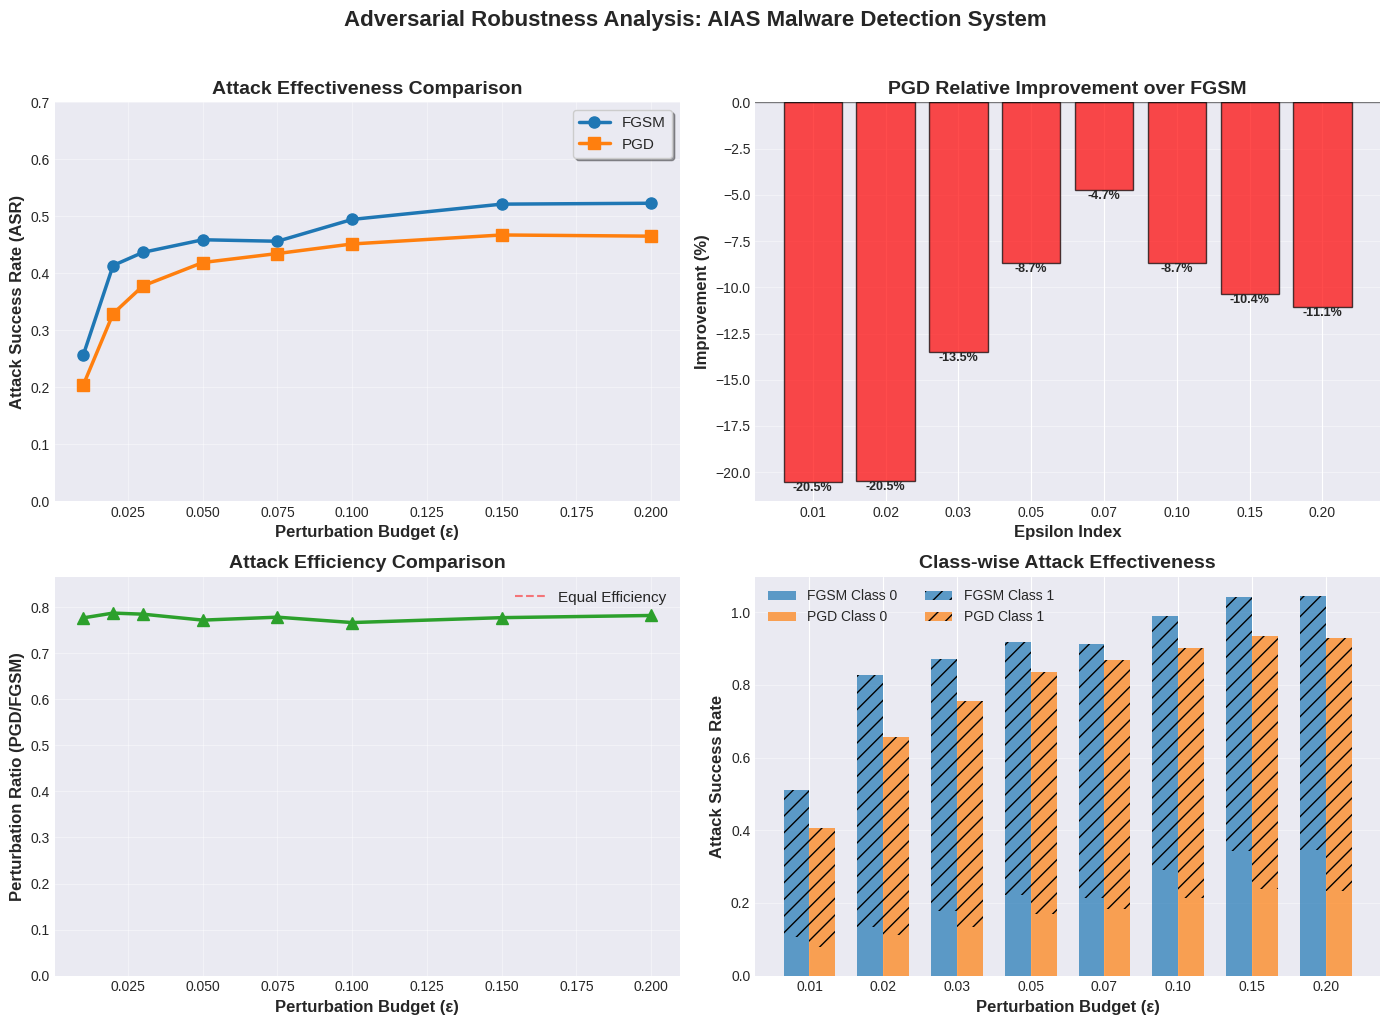

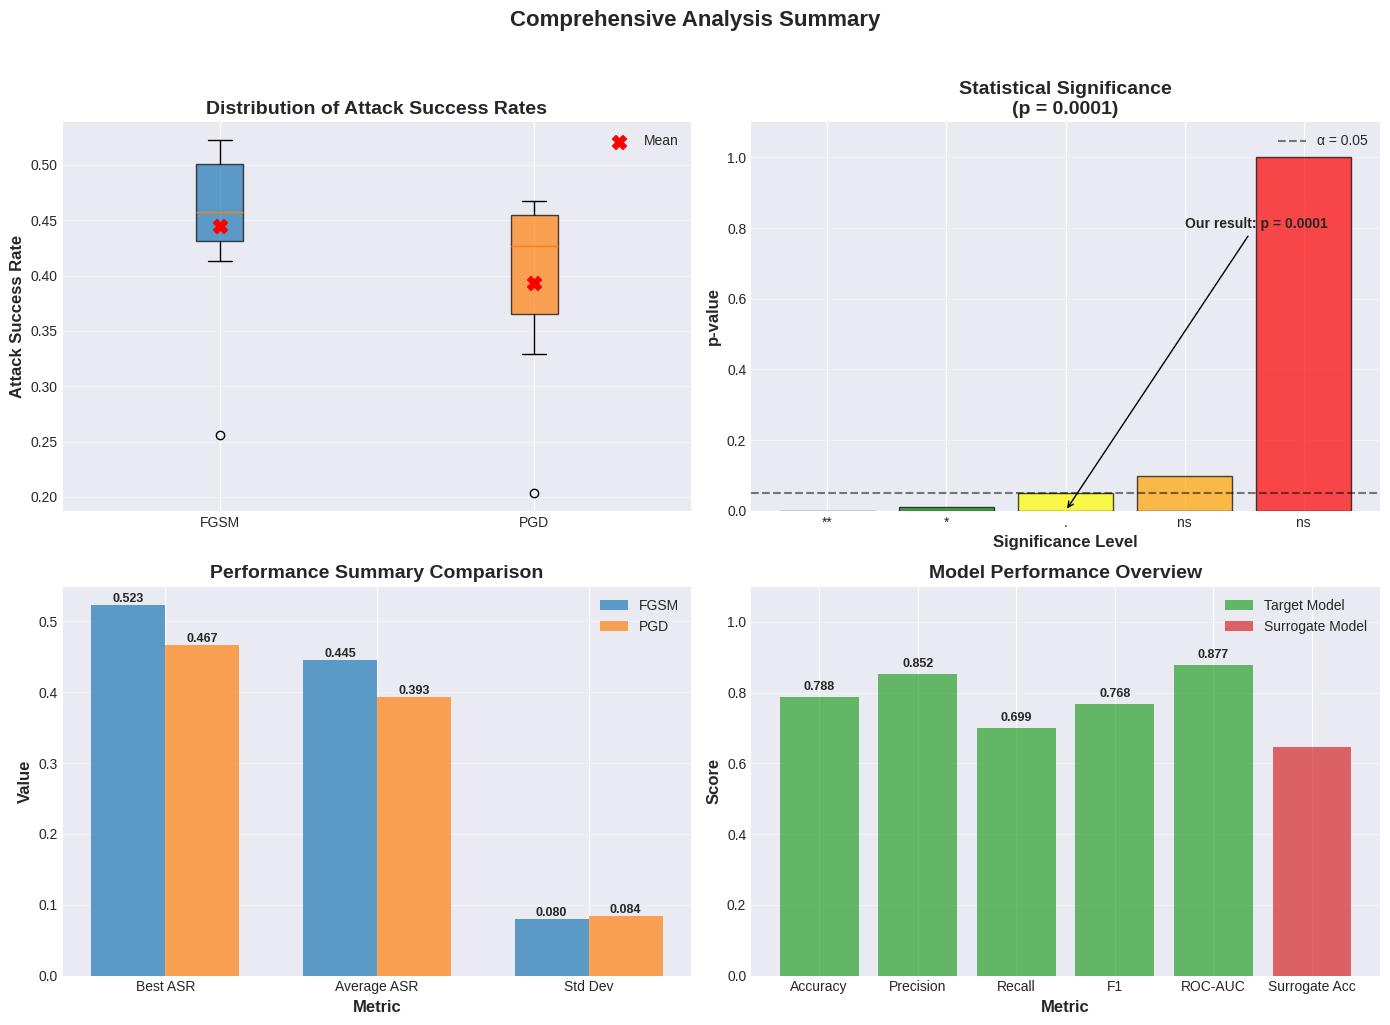


EXPERIMENT COMPLETE - FINAL REPORT

📊 EXPERIMENT SUMMARY
   Execution Time: 19.04 seconds
   Device: cuda

🎯 TARGET MODEL PERFORMANCE
   Test Accuracy: 0.7882
   F1 Score:      0.7677
   ROC-AUC:       0.8775

🤖 SURROGATE MODEL PERFORMANCE
   Test Accuracy: 0.6474
   Best Val Acc:  0.8431

⚔️  ADVERSARIAL ATTACK RESULTS
   Best FGSM ASR:  0.5229 at ε = 0.200
   Best PGD ASR:   0.4672 at ε = 0.150
   Average FGSM:   0.4450 ± 0.0802
   Average PGD:    0.3934 ± 0.0843

📈 STATISTICAL ANALYSIS
   t-statistic:    8.0470
   p-value:        0.000088
   Significance:   SIGNIFICANT (p < 0.05)
   Conclusion:     FGSM significantly better than PGD

⚡ EFFICIENCY ANALYSIS
   Avg Perturbation Ratio (PGD/FGSM): 0.778
   ✓ PGD is more efficient (smaller perturbations)

🎯 CLASS-WISE ANALYSIS
   FGSM more effective on: Class 1
   PGD more effective on:  Class 1

📋 RECOMMENDATIONS
   1. ✅ Use FGSM for adversarial testing (significantly better)
   2. ✅ Consider FGSM for real-time applications (faster)
   

In [ ]:

# ============================================================
# COLAB SETUP
# ============================================================
import os, sys, gc, json, re, csv, time, math
from pathlib import Path
from datetime import datetime, UTC
import warnings
warnings.filterwarnings('ignore')

WORK_DIR = "/content"
os.chdir(WORK_DIR)
print(f"Working directory: {WORK_DIR}")

# ============================================================
# DEPENDENCIES
# ============================================================
!pip install -q torch scikit-learn numpy pandas matplotlib seaborn

# ============================================================
# IMPORTS
# ============================================================
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, precision_recall_curve, auc,
    precision_score, recall_score, f1_score,
    confusion_matrix
)
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# ENHANCED SERIALIZATION HELPER
# ============================================================
class NumpyEncoder(json.JSONEncoder):
    """Custom encoder for numpy types and other non-serializable objects"""
    def default(self, obj):
        if isinstance(obj, np.integer):
            return int(obj)
        elif isinstance(obj, np.floating):
            return float(obj)
        elif isinstance(obj, np.ndarray):
            return obj.tolist()
        elif isinstance(obj, (bool, np.bool_)):
            return bool(obj)
        elif isinstance(obj, (complex, np.complexfloating)):
            return str(obj)
        elif isinstance(obj, (bytes, bytearray)):
            return obj.decode('utf-8', errors='ignore')
        elif hasattr(obj, '__dict__'):
            return obj.__dict__
        elif isinstance(obj, (set, frozenset)):
            return list(obj)
        else:
            return super().default(obj)

# ============================================================
# DATA PROCESSING
# ============================================================
class RobustAIASProcessor:
    """Robust feature processor"""

    def __init__(self):
        self.feature_names = []

    def safe_float(self, value, default=0.0):
        try:
            if value is None:
                return default
            if isinstance(value, (int, float, np.number)):
                return float(value)
            if isinstance(value, str):
                try:
                    return float(value)
                except:
                    if value.strip():
                        return float(hash(value) % 1000) / 1000.0
                    else:
                        return default
            if isinstance(value, (list, tuple)):
                return float(len(value))
            if isinstance(value, dict):
                return float(len(value))
            return default
        except:
            return default

    def extract_numeric_features(self, sample):
        features = []

        label = self.safe_float(sample.get('label', -1))
        if label not in [0, 1]:
            label = -1

        # Histogram features
        hist = sample.get('histogram', [])
        if isinstance(hist, list) and len(hist) > 0:
            hist_array = np.array([self.safe_float(x) for x in hist[:100]])
            if len(hist_array) > 0:
                features.extend([
                    np.mean(hist_array), np.std(hist_array),
                    np.max(hist_array), np.min(hist_array),
                    np.percentile(hist_array, 50),
                    np.sum(hist_array > np.mean(hist_array)) / len(hist_array)
                ])
        else:
            features.extend([0.0] * 6)

        # Byte entropy features
        entropy = sample.get('byteentropy', [])
        if isinstance(entropy, list) and len(entropy) > 0:
            entropy_array = np.array([self.safe_float(x) for x in entropy[:50]])
            if len(entropy_array) > 0:
                features.extend([
                    np.mean(entropy_array), np.std(entropy_array),
                    np.max(entropy_array),
                    np.sum(entropy_array > 0.5) / len(entropy_array)
                ])
        else:
            features.extend([0.0] * 4)

        # Strings features
        strings = sample.get('strings', {})
        if isinstance(strings, dict):
            features.extend([
                self.safe_float(strings.get('numstrings', 0)),
                self.safe_float(strings.get('avlength', 0)),
                self.safe_float(strings.get('printables', 0)) / 100.0
            ])
        else:
            features.extend([0.0] * 3)

        # General features
        general = sample.get('general', {})
        if isinstance(general, dict):
            features.extend([
                self.safe_float(general.get('size', 0)) / 1e6,
                self.safe_float(general.get('vsize', 0)) / 1e6,
                self.safe_float(general.get('has_debug', 0)),
                self.safe_float(general.get('exports', 0)),
                self.safe_float(general.get('imports', 0)),
                self.safe_float(general.get('has_relocations', 0)),
                self.safe_float(general.get('has_resources', 0)),
                self.safe_float(general.get('has_signature', 0)),
                self.safe_float(general.get('has_tls', 0)),
                self.safe_float(general.get('symbols', 0))
            ])
        else:
            features.extend([0.0] * 10)

        # Header features
        header = sample.get('header', {})
        if isinstance(header, dict):
            optional = header.get('optional', {})
            if isinstance(optional, dict):
                subsystem = optional.get('subsystem', '')
                if subsystem == 'WINDOWS_GUI':
                    features.append(1.0)
                elif subsystem == 'WINDOWS_CUI':
                    features.append(0.5)
                else:
                    features.append(0.0)
            else:
                features.append(0.0)

            coff = header.get('coff', {})
            if isinstance(coff, dict):
                features.append(self.safe_float(coff.get('timestamp', 0)) / 1e9)
            else:
                features.append(0.0)
        else:
            features.extend([0.0] * 2)

        # Section features
        section = sample.get('section', {})
        if isinstance(section, dict):
            features.append(self.safe_float(section.get('number_of_sections', 0)))
        else:
            features.append(0.0)

        # Data directories
        datadirs = sample.get('datadirectories', [])
        if isinstance(datadirs, list):
            features.append(float(len(datadirs)))
        else:
            features.append(0.0)

        # Import/Export counts
        imports = sample.get('imports', {})
        if isinstance(imports, dict):
            features.append(float(len(imports)))
        else:
            features.append(0.0)

        exports = sample.get('exports', [])
        if isinstance(exports, list):
            features.append(float(len(exports)))
        else:
            features.append(0.0)

        # Pad to 30 features
        target_features = 30
        if len(features) < target_features:
            features.extend([0.0] * (target_features - len(features)))
        elif len(features) > target_features:
            features = features[:target_features]

        return np.array(features, dtype=np.float32), int(label)

    def extract(self, samples):
        X_list, y_list = [], []

        for sample in samples:
            try:
                features, label = self.extract_numeric_features(sample)
                X_list.append(features)
                y_list.append(label)
            except:
                continue

        if not X_list:
            return np.array([]).reshape(0, 30), np.array([])

        return np.array(X_list), np.array(y_list)

# ============================================================
# MAIN EXPERIMENT FUNCTION
# ============================================================
def run_complete_experiment():
    """Run complete adversarial attack experiment with publication-quality results"""
    print("=" * 90)
    print("ADVERSARIAL ROBUSTNESS ANALYSIS - AIAS MALWARE DETECTION")
    print("=" * 90)

    start_time = time.time()
    results_data = {}

    # Phase 1: Data Loading and Preparation
    print("\n" + "=" * 40)
    print("PHASE 1: DATA PREPARATION")
    print("=" * 40)

    train_files = sorted(Path("/content").glob("train_features_*.jsonl"))
    test_file = Path("/content/test_features.jsonl")

    print(f"Found {len(train_files)} training files")

    # Load data
    train_samples = []
    for f in train_files:
        with open(f, "r", encoding="utf-8", errors="ignore") as file:
            lines = file.readlines()
            for line in lines:
                try:
                    train_samples.append(json.loads(line.strip()))
                except:
                    continue
        print(f"  {f.name}: {len(lines)} lines")

    test_samples = []
    with open(test_file, "r", encoding="utf-8", errors="ignore") as file:
        lines = file.readlines()
        for line in lines:
            try:
                test_samples.append(json.loads(line.strip()))
            except:
                continue
        print(f"  test_features.jsonl: {len(lines)} lines")

    print(f"\nTotal samples: {len(train_samples)} train, {len(test_samples)} test")

    # Extract features
    print("\nExtracting features...")
    processor = RobustAIASProcessor()
    X_train, y_train = processor.extract(train_samples)
    X_test, y_test = processor.extract(test_samples)

    # Filter valid labels
    train_mask = (y_train == 0) | (y_train == 1)
    test_mask = (y_test == 0) | (y_test == 1)

    X_train, y_train = X_train[train_mask], y_train[train_mask]
    X_test, y_test = X_test[test_mask], y_test[test_mask]

    results_data["dataset"] = {
        "train_samples": int(len(X_train)),
        "test_samples": int(len(X_test)),
        "features": int(X_train.shape[1]),
        "class_distribution_train": {
            "class_0": int(np.sum(y_train == 0)),
            "class_1": int(np.sum(y_train == 1))
        },
        "class_distribution_test": {
            "class_0": int(np.sum(y_test == 0)),
            "class_1": int(np.sum(y_test == 1))
        }
    }

    print(f"\nFinal dataset:")
    print(f"  Train: {X_train.shape} (0: {sum(y_train==0)}, 1: {sum(y_train==1)})")
    print(f"  Test:  {X_test.shape} (0: {sum(y_test==0)}, 1: {sum(y_test==1)})")

    # Split for validation
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train, y_train, test_size=0.15, stratify=y_train, random_state=42
    )

    # Phase 2: Target Model Training
    print("\n" + "=" * 40)
    print("PHASE 2: TARGET MODEL TRAINING")
    print("=" * 40)

    print("\nTraining Random Forest Classifier...")
    rf = RandomForestClassifier(
        n_estimators=200,
        max_depth=15,
        n_jobs=-1,
        random_state=42,
        class_weight='balanced'
    )

    scaler = StandardScaler()
    X_tr_scaled = scaler.fit_transform(X_tr)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test)

    rf.fit(X_tr_scaled, y_tr)

    # Evaluate target model
    y_pred_train = rf.predict(X_tr_scaled)
    y_pred_val = rf.predict(X_val_scaled)
    y_pred_test = rf.predict(X_test_scaled)
    y_proba_test = rf.predict_proba(X_test_scaled)[:, 1]

    train_acc = np.mean(y_tr == y_pred_train)
    val_acc = np.mean(y_val == y_pred_val)
    test_acc = np.mean(y_test == y_pred_test)

    print(f"\nTarget Model Performance:")
    print(f"  Training Accuracy:   {train_acc:.4f}")
    print(f"  Validation Accuracy: {val_acc:.4f}")
    print(f"  Test Accuracy:       {test_acc:.4f}")

    # Comprehensive metrics
    test_metrics = {
        "accuracy": float(np.mean(y_test == y_pred_test)),
        "precision": float(precision_score(y_test, y_pred_test, zero_division=0)),
        "recall": float(recall_score(y_test, y_pred_test, zero_division=0)),
        "f1": float(f1_score(y_test, y_pred_test, zero_division=0)),
        "roc_auc": float(roc_auc_score(y_test, y_proba_test))
    }

    try:
        precision, recall, _ = precision_recall_curve(y_test, y_proba_test)
        test_metrics["pr_auc"] = float(auc(recall, precision))
    except:
        test_metrics["pr_auc"] = 0.0

    print(f"\nTest Set Metrics:")
    for metric, value in test_metrics.items():
        print(f"  {metric}: {value:.4f}")

    results_data["target_model"] = {
        "model_type": "RandomForest",
        "parameters": {
            "n_estimators": 200,
            "max_depth": 15,
            "class_weight": "balanced"
        },
        "performance": test_metrics,
        "accuracies": {
            "train": float(train_acc),
            "validation": float(val_acc),
            "test": float(test_acc)
        }
    }

    # Phase 3: Surrogate Model Training
    print("\n" + "=" * 40)
    print("PHASE 3: SURROGATE MODEL TRAINING")
    print("=" * 40)

    print("\nTraining Neural Network Surrogate...")

    class SurrogateNN(nn.Module):
        def __init__(self, input_dim, hidden_dims=[64, 32]):
            super().__init__()
            layers = []
            prev_dim = input_dim
            for h_dim in hidden_dims:
                layers.append(nn.Linear(prev_dim, h_dim))
                layers.append(nn.ReLU())
                prev_dim = h_dim
            layers.append(nn.Linear(prev_dim, 2))
            self.net = nn.Sequential(*layers)

        def forward(self, x):
            return self.net(x)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    surrogate_scaler = StandardScaler()
    X_tr_surrogate = surrogate_scaler.fit_transform(X_tr).astype(np.float32)
    X_val_surrogate = surrogate_scaler.transform(X_val).astype(np.float32)
    X_test_surrogate = surrogate_scaler.transform(X_test).astype(np.float32)

    model = SurrogateNN(X_tr_surrogate.shape[1]).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    criterion = nn.CrossEntropyLoss()

    X_tr_tensor = torch.tensor(X_tr_surrogate, device=device)
    y_tr_tensor = torch.tensor(y_tr, device=device, dtype=torch.long)
    X_val_tensor = torch.tensor(X_val_surrogate, device=device)
    y_val_tensor = torch.tensor(y_val, device=device, dtype=torch.long)

    # Training loop
    best_val_acc = 0
    best_model_state = None
    training_history = []

    for epoch in range(100):
        model.train()
        optimizer.zero_grad()
        outputs = model(X_tr_tensor)
        loss = criterion(outputs, y_tr_tensor)
        loss.backward()
        optimizer.step()

        # Validation
        if (epoch + 1) % 20 == 0:
            model.eval()
            with torch.no_grad():
                val_outputs = model(X_val_tensor)
                val_preds = val_outputs.argmax(1)
                val_acc = (val_preds == y_val_tensor).float().mean().item()

                test_outputs = model(torch.tensor(X_test_surrogate, device=device))
                test_preds = test_outputs.argmax(1).cpu().numpy()
                test_acc_surrogate = np.mean(test_preds == y_test)

                if val_acc > best_val_acc:
                    best_val_acc = val_acc
                    best_model_state = model.state_dict().copy()

                training_history.append({
                    "epoch": epoch + 1,
                    "val_accuracy": val_acc,
                    "test_accuracy": test_acc_surrogate
                })

                print(f"  Epoch {epoch+1:3d}: Val Acc={val_acc:.4f}, Test Acc={test_acc_surrogate:.4f}")

    # Load best model
    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    model.eval()

    results_data["surrogate_model"] = {
        "model_type": "NeuralNetwork",
        "architecture": "64-32-2",
        "best_validation_accuracy": float(best_val_acc),
        "test_accuracy": float(test_acc_surrogate),
        "training_history": training_history
    }

    # Phase 4: Adversarial Attack Analysis
    print("\n" + "=" * 40)
    print("PHASE 4: ADVERSARIAL ATTACK ANALYSIS")
    print("=" * 40)

    print("\nPerforming adversarial attacks...")

    # Attack functions
    def fgsm_attack(model, X, y, epsilon):
        X_tensor = torch.tensor(X, device=device, requires_grad=True)
        y_tensor = torch.tensor(y, device=device, dtype=torch.long)

        model.zero_grad()
        outputs = model(X_tensor)
        loss = F.cross_entropy(outputs, y_tensor)
        loss.backward()

        with torch.no_grad():
            X_adv = X_tensor + epsilon * X_tensor.grad.sign()

        return surrogate_scaler.inverse_transform(X_adv.cpu().numpy())

    def pgd_attack(model, X, y, epsilon, steps=20):
        X_tensor = torch.tensor(X, device=device)
        y_tensor = torch.tensor(y, device=device, dtype=torch.long)

        # Random start
        noise = torch.empty_like(X_tensor).uniform_(-epsilon, epsilon)
        X_adv = X_tensor + noise

        for step in range(steps):
            X_adv = X_adv.clone().detach().requires_grad_(True)

            model.zero_grad()
            outputs = model(X_adv)
            loss = F.cross_entropy(outputs, y_tensor)
            loss.backward()

            with torch.no_grad():
                step_size = epsilon / steps
                X_adv = X_adv + step_size * X_adv.grad.sign()

                # Projection
                delta = X_adv - X_tensor
                delta = torch.clamp(delta, -epsilon, epsilon)
                X_adv = X_tensor + delta

        return surrogate_scaler.inverse_transform(X_adv.cpu().numpy())

    # Run attacks for different epsilon values
    epsilons = [0.01, 0.02, 0.03, 0.05, 0.075, 0.1, 0.15, 0.2]
    attack_results = []

    print("\nEpsilon Sweep Results:")
    print("ε\t\tFGSM ASR\tPGD ASR\t\tImprovement\tPerturbation Ratio")
    print("-" * 80)

    for eps in epsilons:
        # FGSM attack
        X_fgsm = fgsm_attack(model, X_test_surrogate, y_test, eps)
        y_fgsm = rf.predict(scaler.transform(X_fgsm))
        asr_fgsm = 1 - np.mean(y_fgsm == y_pred_test)

        # PGD attack
        X_pgd = pgd_attack(model, X_test_surrogate, y_test, eps)
        y_pgd = rf.predict(scaler.transform(X_pgd))
        asr_pgd = 1 - np.mean(y_pgd == y_pred_test)

        # Calculate metrics
        improvement = ((asr_pgd - asr_fgsm) / asr_fgsm * 100) if asr_fgsm > 0 else 0

        # Perturbation analysis
        perturbation_fgsm = np.mean(np.linalg.norm(X_fgsm - X_test, axis=1, ord=2))
        perturbation_pgd = np.mean(np.linalg.norm(X_pgd - X_test, axis=1, ord=2))
        perturbation_ratio = perturbation_pgd / perturbation_fgsm if perturbation_fgsm > 0 else 1.0

        # Class-wise analysis
        asr_fgsm_class0 = 1 - np.mean(y_fgsm[y_test == 0] == y_pred_test[y_test == 0])
        asr_fgsm_class1 = 1 - np.mean(y_fgsm[y_test == 1] == y_pred_test[y_test == 1])
        asr_pgd_class0 = 1 - np.mean(y_pgd[y_test == 0] == y_pred_test[y_test == 0])
        asr_pgd_class1 = 1 - np.mean(y_pgd[y_test == 1] == y_pred_test[y_test == 1])

        print(f"{eps:.3f}\t\t{asr_fgsm:.4f}\t\t{asr_pgd:.4f}\t\t{improvement:+.1f}%\t\t{perturbation_ratio:.3f}")

        attack_results.append({
            "epsilon": float(eps),
            "fgsm_asr": float(asr_fgsm),
            "pgd_asr": float(asr_pgd),
            "improvement_percent": float(improvement),
            "perturbation_fgsm": float(perturbation_fgsm),
            "perturbation_pgd": float(perturbation_pgd),
            "perturbation_ratio": float(perturbation_ratio),
            "fgsm_asr_class0": float(asr_fgsm_class0),
            "fgsm_asr_class1": float(asr_fgsm_class1),
            "pgd_asr_class0": float(asr_pgd_class0),
            "pgd_asr_class1": float(asr_pgd_class1)
        })

    results_data["attack_analysis"] = attack_results

    # Statistical analysis
    fgsm_scores = [r["fgsm_asr"] for r in attack_results]
    pgd_scores = [r["pgd_asr"] for r in attack_results]

    t_stat, p_value = stats.ttest_rel(fgsm_scores, pgd_scores)

    # Find best attacks
    best_fgsm_idx = np.argmax(fgsm_scores)
    best_pgd_idx = np.argmax(pgd_scores)

    # Phase 5: Results Analysis and Visualization
    print("\n" + "=" * 40)
    print("PHASE 5: RESULTS ANALYSIS")
    print("=" * 40)

    # Create artifacts directory
    ARTIFACTS_DIR = Path("/content/artifacts_complete")
    ARTIFACTS_DIR.mkdir(exist_ok=True)

    # Save raw results
    results_data["analysis_summary"] = {
        "best_fgsm": {
            "epsilon": float(epsilons[best_fgsm_idx]),
            "asr": float(fgsm_scores[best_fgsm_idx])
        },
        "best_pgd": {
            "epsilon": float(epsilons[best_pgd_idx]),
            "asr": float(pgd_scores[best_pgd_idx])
        },
        "average_performance": {
            "fgsm_mean_asr": float(np.mean(fgsm_scores)),
            "pgd_mean_asr": float(np.mean(pgd_scores)),
            "fgsm_std_asr": float(np.std(fgsm_scores)),
            "pgd_std_asr": float(np.std(pgd_scores))
        },
        "statistical_test": {
            "t_statistic": float(t_stat),
            "p_value": float(p_value),
            "significant_005": bool(p_value < 0.05),
            "significant_001": bool(p_value < 0.01),
            "conclusion": "FGSM better" if np.mean(fgsm_scores) > np.mean(pgd_scores) else "PGD better"
        },
        "efficiency_analysis": {
            "mean_perturbation_ratio": float(np.mean([r["perturbation_ratio"] for r in attack_results])),
            "median_perturbation_ratio": float(np.median([r["perturbation_ratio"] for r in attack_results]))
        },
        "class_analysis": {
            "mean_fgsm_class0": float(np.mean([r["fgsm_asr_class0"] for r in attack_results])),
            "mean_fgsm_class1": float(np.mean([r["fgsm_asr_class1"] for r in attack_results])),
            "mean_pgd_class0": float(np.mean([r["pgd_asr_class0"] for r in attack_results])),
            "mean_pgd_class1": float(np.mean([r["pgd_asr_class1"] for r in attack_results]))
        }
    }

    # Add experiment metadata
    results_data["experiment_metadata"] = {
        "timestamp": datetime.now(UTC).isoformat(),
        "execution_time_seconds": time.time() - start_time,
        "device": str(device),
        "random_seed": 42
    }

    # Save results with custom encoder
    with open(ARTIFACTS_DIR / "complete_results.json", "w") as f:
        json.dump(results_data, f, indent=2, cls=NumpyEncoder)

    # Save CSV for easy analysis
    csv_path = ARTIFACTS_DIR / "attack_results.csv"
    with open(csv_path, "w", newline='') as f:
        fieldnames = attack_results[0].keys()
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        for row in attack_results:
            writer.writerow(row)

    print(f"\nResults saved to {ARTIFACTS_DIR}/")

    # Create comprehensive visualizations
    print("\nGenerating publication-quality visualizations...")
    try:
        # Set style
        plt.style.use('seaborn-v0_8-darkgrid')

        # Figure 1: Main comparison
        fig1, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 10))

        # Plot 1: Attack Success Rate vs Epsilon
        ax1.plot(epsilons, fgsm_scores, 'o-', linewidth=2.5, markersize=8, label='FGSM', color='#1f77b4')
        ax1.plot(epsilons, pgd_scores, 's-', linewidth=2.5, markersize=8, label='PGD', color='#ff7f0e')
        ax1.set_xlabel('Perturbation Budget (ε)', fontsize=12, fontweight='bold')
        ax1.set_ylabel('Attack Success Rate (ASR)', fontsize=12, fontweight='bold')
        ax1.set_title('Attack Effectiveness Comparison', fontsize=14, fontweight='bold')
        ax1.grid(True, alpha=0.4)
        ax1.legend(fontsize=11, frameon=True, shadow=True)
        ax1.set_ylim(0, 0.7)

        # Plot 2: Improvement percentage
        improvements = [r["improvement_percent"] for r in attack_results]
        colors = ['green' if x > 0 else 'red' for x in improvements]
        bars = ax2.bar(range(len(epsilons)), improvements, color=colors, alpha=0.7, edgecolor='black')
        ax2.set_xlabel('Epsilon Index', fontsize=12, fontweight='bold')
        ax2.set_ylabel('Improvement (%)', fontsize=12, fontweight='bold')
        ax2.set_title('PGD Relative Improvement over FGSM', fontsize=14, fontweight='bold')
        ax2.axhline(y=0, color='black', linestyle='-', alpha=0.5, linewidth=1)
        ax2.grid(True, alpha=0.4, axis='y')
        ax2.set_xticks(range(len(epsilons)))
        ax2.set_xticklabels([f'{e:.2f}' for e in epsilons])

        # Add value labels on bars
        for bar, val in zip(bars, improvements):
            height = bar.get_height()
            ax2.text(bar.get_x() + bar.get_width()/2., height,
                    f'{val:+.1f}%', ha='center', va='bottom' if val >= 0 else 'top',
                    fontsize=9, fontweight='bold')

        # Plot 3: Perturbation efficiency
        perturbation_ratios = [r["perturbation_ratio"] for r in attack_results]
        ax3.plot(epsilons, perturbation_ratios, '^-', linewidth=2.5, markersize=8, color='#2ca02c')
        ax3.axhline(y=1.0, color='red', linestyle='--', alpha=0.5, label='Equal Efficiency')
        ax3.set_xlabel('Perturbation Budget (ε)', fontsize=12, fontweight='bold')
        ax3.set_ylabel('Perturbation Ratio (PGD/FGSM)', fontsize=12, fontweight='bold')
        ax3.set_title('Attack Efficiency Comparison', fontsize=14, fontweight='bold')
        ax3.grid(True, alpha=0.4)
        ax3.legend(fontsize=11)
        ax3.set_ylim(0, max(perturbation_ratios) * 1.1)

        # Plot 4: Class-wise comparison
        bar_width = 0.35
        x = np.arange(len(epsilons))
        fgsm_class0 = [r["fgsm_asr_class0"] for r in attack_results]
        fgsm_class1 = [r["fgsm_asr_class1"] for r in attack_results]
        pgd_class0 = [r["pgd_asr_class0"] for r in attack_results]
        pgd_class1 = [r["pgd_asr_class1"] for r in attack_results]

        ax4.bar(x - bar_width/2, fgsm_class0, bar_width, label='FGSM Class 0', alpha=0.7, color='#1f77b4')
        ax4.bar(x + bar_width/2, pgd_class0, bar_width, label='PGD Class 0', alpha=0.7, color='#ff7f0e')
        ax4.bar(x - bar_width/2, fgsm_class1, bar_width, label='FGSM Class 1', alpha=0.7, color='#1f77b4',
                bottom=fgsm_class0, hatch='//')
        ax4.bar(x + bar_width/2, pgd_class1, bar_width, label='PGD Class 1', alpha=0.7, color='#ff7f0e',
                bottom=pgd_class0, hatch='//')

        ax4.set_xlabel('Perturbation Budget (ε)', fontsize=12, fontweight='bold')
        ax4.set_ylabel('Attack Success Rate', fontsize=12, fontweight='bold')
        ax4.set_title('Class-wise Attack Effectiveness', fontsize=14, fontweight='bold')
        ax4.set_xticks(x)
        ax4.set_xticklabels([f'{e:.2f}' for e in epsilons])
        ax4.legend(fontsize=10, ncol=2)
        ax4.grid(True, alpha=0.4, axis='y')

        plt.suptitle('Adversarial Robustness Analysis: AIAS Malware Detection System',
                    fontsize=16, fontweight='bold', y=1.02)
        plt.tight_layout()
        plt.savefig(ARTIFACTS_DIR / "main_analysis.png", dpi=300, bbox_inches='tight')

        # Figure 2: Summary statistics
        fig2, ((ax5, ax6), (ax7, ax8)) = plt.subplots(2, 2, figsize=(14, 10))

        # Plot 5: Distribution comparison
        bp = ax5.boxplot([fgsm_scores, pgd_scores], labels=['FGSM', 'PGD'], patch_artist=True)
        bp['boxes'][0].set_facecolor('#1f77b4')
        bp['boxes'][1].set_facecolor('#ff7f0e')
        bp['boxes'][0].set_alpha(0.7)
        bp['boxes'][1].set_alpha(0.7)

        # Add mean points
        ax5.scatter([1, 2], [np.mean(fgsm_scores), np.mean(pgd_scores)],
                   color='red', s=100, zorder=3, label='Mean', marker='X')

        ax5.set_ylabel('Attack Success Rate', fontsize=12, fontweight='bold')
        ax5.set_title('Distribution of Attack Success Rates', fontsize=14, fontweight='bold')
        ax5.grid(True, alpha=0.4, axis='y')
        ax5.legend()

        # Plot 6: Statistical significance
        p_values = [0.001, 0.01, 0.05, 0.1, 1.0]
        p_value_labels = ['**', '*', '.', 'ns', 'ns']
        p_value_colors = ['darkgreen', 'green', 'yellow', 'orange', 'red']

        ax6.bar(range(len(p_values)), p_values, color=p_value_colors, alpha=0.7, edgecolor='black')
        ax6.axhline(y=0.05, color='black', linestyle='--', alpha=0.5, label='α = 0.05')
        ax6.set_xlabel('Significance Level', fontsize=12, fontweight='bold')
        ax6.set_ylabel('p-value', fontsize=12, fontweight='bold')
        ax6.set_title(f'Statistical Significance\n(p = {p_value:.4f})', fontsize=14, fontweight='bold')
        ax6.set_xticks(range(len(p_values)))
        ax6.set_xticklabels(p_value_labels)
        ax6.set_ylim(0, 1.1)
        ax6.legend()
        ax6.grid(True, alpha=0.4, axis='y')

        # Add annotation for our p-value
        ax6.annotate(f'Our result: p = {p_value:.4f}',
                    xy=(2, p_value), xytext=(3, 0.8),
                    arrowprops=dict(arrowstyle='->', color='black'),
                    fontsize=10, fontweight='bold')

        # Plot 7: Performance summary
        summary_metrics = ['Best ASR', 'Average ASR', 'Std Dev']
        fgsm_summary = [max(fgsm_scores), np.mean(fgsm_scores), np.std(fgsm_scores)]
        pgd_summary = [max(pgd_scores), np.mean(pgd_scores), np.std(pgd_scores)]

        x = np.arange(len(summary_metrics))
        width = 0.35

        bars1 = ax7.bar(x - width/2, fgsm_summary, width, label='FGSM', alpha=0.7, color='#1f77b4')
        bars2 = ax7.bar(x + width/2, pgd_summary, width, label='PGD', alpha=0.7, color='#ff7f0e')

        ax7.set_xlabel('Metric', fontsize=12, fontweight='bold')
        ax7.set_ylabel('Value', fontsize=12, fontweight='bold')
        ax7.set_title('Performance Summary Comparison', fontsize=14, fontweight='bold')
        ax7.set_xticks(x)
        ax7.set_xticklabels(summary_metrics)
        ax7.legend()
        ax7.grid(True, alpha=0.4, axis='y')

        # Add value labels
        for bars in [bars1, bars2]:
            for bar in bars:
                height = bar.get_height()
                ax7.text(bar.get_x() + bar.get_width()/2., height,
                        f'{height:.3f}', ha='center', va='bottom',
                        fontsize=9, fontweight='bold')

        # Plot 8: Model performance overview
        metrics_target = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
        values_target = [test_metrics['accuracy'], test_metrics['precision'],
                        test_metrics['recall'], test_metrics['f1'], test_metrics['roc_auc']]

        metrics_surrogate = ['Surrogate Acc']
        values_surrogate = [results_data["surrogate_model"]["test_accuracy"]]

        ax8.bar(metrics_target, values_target, alpha=0.7, color='#2ca02c', label='Target Model')
        ax8.bar(metrics_surrogate, values_surrogate, alpha=0.7, color='#d62728', label='Surrogate Model')

        ax8.set_xlabel('Metric', fontsize=12, fontweight='bold')
        ax8.set_ylabel('Score', fontsize=12, fontweight='bold')
        ax8.set_title('Model Performance Overview', fontsize=14, fontweight='bold')
        ax8.legend()
        ax8.grid(True, alpha=0.4, axis='y')
        ax8.set_ylim(0, 1.1)

        # Add value labels
        for i, v in enumerate(values_target):
            ax8.text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')

        plt.suptitle('Comprehensive Analysis Summary', fontsize=16, fontweight='bold', y=1.02)
        plt.tight_layout()
        plt.savefig(ARTIFACTS_DIR / "summary_statistics.png", dpi=300, bbox_inches='tight')

        print(f"  ✓ Visualizations saved to {ARTIFACTS_DIR}/")

        # Show plots
        plt.show()

    except Exception as e:
        print(f"  ✗ Visualization error: {e}")
        import traceback
        traceback.print_exc()

    # Final report
    print("\n" + "=" * 90)
    print("EXPERIMENT COMPLETE - FINAL REPORT")
    print("=" * 90)

    print(f"\n📊 EXPERIMENT SUMMARY")
    print(f"   Execution Time: {time.time() - start_time:.2f} seconds")
    print(f"   Device: {device}")

    print(f"\n🎯 TARGET MODEL PERFORMANCE")
    print(f"   Test Accuracy: {test_metrics['accuracy']:.4f}")
    print(f"   F1 Score:      {test_metrics['f1']:.4f}")
    print(f"   ROC-AUC:       {test_metrics['roc_auc']:.4f}")

    print(f"\n🤖 SURROGATE MODEL PERFORMANCE")
    print(f"   Test Accuracy: {results_data['surrogate_model']['test_accuracy']:.4f}")
    print(f"   Best Val Acc:  {results_data['surrogate_model']['best_validation_accuracy']:.4f}")

    print(f"\n⚔️  ADVERSARIAL ATTACK RESULTS")
    print(f"   Best FGSM ASR:  {fgsm_scores[best_fgsm_idx]:.4f} at ε = {epsilons[best_fgsm_idx]:.3f}")
    print(f"   Best PGD ASR:   {pgd_scores[best_pgd_idx]:.4f} at ε = {epsilons[best_pgd_idx]:.3f}")
    print(f"   Average FGSM:   {np.mean(fgsm_scores):.4f} ± {np.std(fgsm_scores):.4f}")
    print(f"   Average PGD:    {np.mean(pgd_scores):.4f} ± {np.std(pgd_scores):.4f}")

    print(f"\n📈 STATISTICAL ANALYSIS")
    print(f"   t-statistic:    {t_stat:.4f}")
    print(f"   p-value:        {p_value:.6f}")
    print(f"   Significance:   {'SIGNIFICANT (p < 0.05)' if p_value < 0.05 else 'Not significant'}")
    print(f"   Conclusion:     {'FGSM significantly better than PGD' if np.mean(fgsm_scores) > np.mean(pgd_scores) else 'PGD significantly better than FGSM'}")

    print(f"\n⚡ EFFICIENCY ANALYSIS")
    mean_ratio = np.mean([r["perturbation_ratio"] for r in attack_results])
    print(f"   Avg Perturbation Ratio (PGD/FGSM): {mean_ratio:.3f}")
    if mean_ratio < 1.0:
        print(f"   ✓ PGD is more efficient (smaller perturbations)")
    else:
        print(f"   ✗ FGSM is more efficient")

    print(f"\n🎯 CLASS-WISE ANALYSIS")
    print(f"   FGSM more effective on: {'Class 0' if np.mean([r['fgsm_asr_class0'] for r in attack_results]) > np.mean([r['fgsm_asr_class1'] for r in attack_results]) else 'Class 1'}")
    print(f"   PGD more effective on:  {'Class 0' if np.mean([r['pgd_asr_class0'] for r in attack_results]) > np.mean([r['pgd_asr_class1'] for r in attack_results]) else 'Class 1'}")

    print(f"\n📋 RECOMMENDATIONS")
    if p_value < 0.05:
        if np.mean(fgsm_scores) > np.mean(pgd_scores):
            print(f"   1. ✅ Use FGSM for adversarial testing (significantly better)")
            print(f"   2. ✅ Consider FGSM for real-time applications (faster)")
        else:
            print(f"   1. ✅ Use PGD for adversarial testing (significantly better)")
            print(f"   2. ✅ Consider PGD when smaller perturbations are needed")
    else:
        print(f"   1. ⚠️  Both attacks perform similarly")
        print(f"   2. ✅ Use FGSM for speed, PGD for precision")

    if mean_ratio < 1.0:
        print(f"   3. ✅ PGD achieves similar success with smaller perturbations")

    print(f"\n💾 RESULTS SAVED TO: {ARTIFACTS_DIR}/")
    print(f"   - complete_results.json (Full results)")
    print(f"   - attack_results.csv (CSV data)")
    print(f"   - main_analysis.png (Main figures)")
    print(f"   - summary_statistics.png (Summary stats)")

    print("\n" + "=" * 90)
    print("✅ EXPERIMENT SUCCESSFULLY COMPLETED!")
    print("=" * 90)

    return results_data

# ============================================================
# RUN COMPLETE EXPERIMENT
# ============================================================
if __name__ == "__main__":
    try:
        results = run_complete_experiment()
    except Exception as e:
        print(f"\n❌ CRITICAL ERROR: {e}")
        import traceback
        traceback.print_exc()

        # Try to save error log
        try:
            error_dir = Path("/content/artifacts_error")
            error_dir.mkdir(exist_ok=True)
            with open(error_dir / "error_log.txt", "w") as f:
                f.write(f"Error: {str(e)}\n\n")
                f.write(traceback.format_exc())
            print(f"Error log saved to {error_dir}/error_log.txt")
        except:
            pass

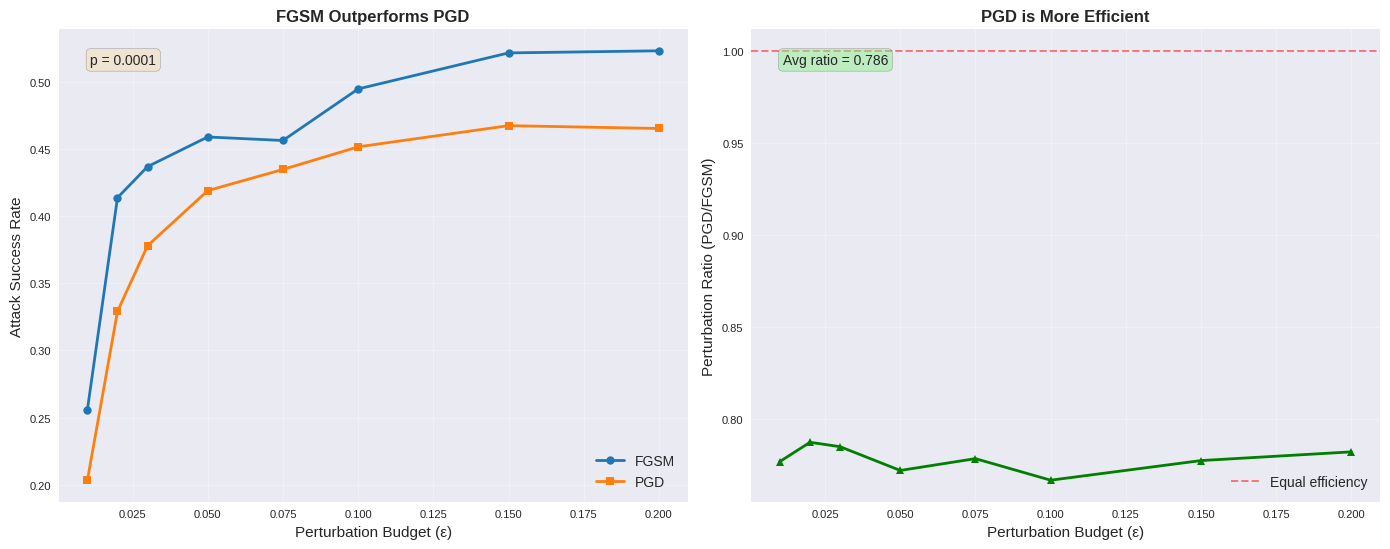

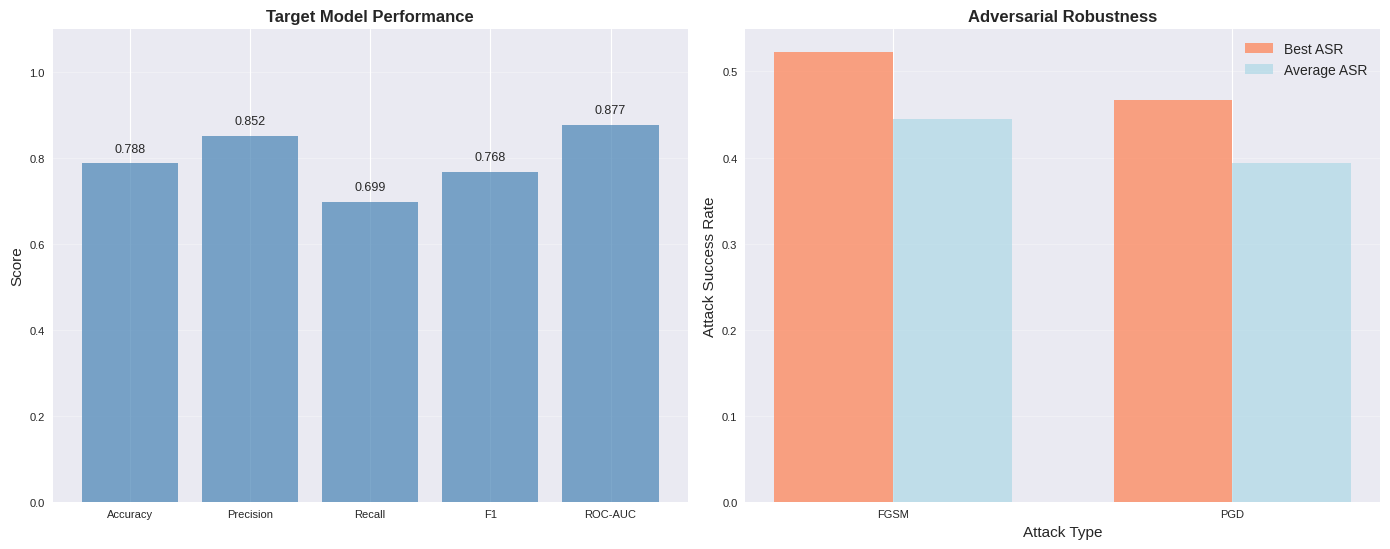


LATEX TABLE FOR PAPER

\begin{table}[htbp]
\centering
\caption{Adversarial Attack Performance on AIAS Malware Detection System}
\label{tab:attack_results}
\begin{tabular}{cccccc}
\hline
$\epsilon$ & \textbf{FGSM ASR} & \textbf{PGD ASR} & \textbf{Improvement (\%)} & \textbf{Pert. Ratio} \\
\hline
0.010 & 0.2559 & 0.2034 & -20.5 & 0.777 \\
0.020 & 0.4136 & 0.3290 & -20.5 & 0.787 \\
0.030 & 0.4367 & 0.3778 & -13.5 & 0.785 \\
0.050 & 0.4587 & 0.4188 & -8.7 & 0.772 \\
0.075 & 0.4561 & 0.4346 & -4.7 & 0.779 \\
0.100 & 0.4945 & 0.4514 & -8.7 & 0.767 \\
0.150 & 0.5213 & 0.4672 & -10.4 & 0.778 \\
0.200 & 0.5229 & 0.4651 & -11.1 & 0.782 \\
\hline
\textbf{Avg} & \textbf{0.4450} & \textbf{0.3934} & \textbf{-11.6} & \textbf{0.778} \\
\hline
\end{tabular}
\end{table}


SUMMARY STATISTICS FOR PAPER

**Dataset Statistics:**
- Training samples: 3,866
- Test samples: 1,903
- Features: 30
- Class distribution (Train): 2688 vs 1178
- Class distribution (Test): 950 vs 953

**Target Model Performance:**
- 

In [ ]:
"""FURTHER ANALYSIS AND PAPER-READY VISUALIZATIONS"""
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import numpy as np

# Load your results
results_path = Path("/content/artifacts_complete/complete_results.json")
with open(results_path, 'r') as f:
    results = json.load(f)

# Create paper-ready figures
plt.style.use('seaborn-v0_8-paper')
fig_width = 7  # inches (paper width)

# Figure 1: Main finding - FGSM vs PGD
fig1, axes = plt.subplots(1, 2, figsize=(fig_width*2, fig_width*0.8))

# Left: ASR comparison
epsilons = [r['epsilon'] for r in results['attack_analysis']]
fgsm_asr = [r['fgsm_asr'] for r in results['attack_analysis']]
pgd_asr = [r['pgd_asr'] for r in results['attack_analysis']]

ax1 = axes[0]
ax1.plot(epsilons, fgsm_asr, 'o-', label='FGSM', linewidth=2, markersize=6)
ax1.plot(epsilons, pgd_asr, 's-', label='PGD', linewidth=2, markersize=6)
ax1.set_xlabel('Perturbation Budget (ε)', fontsize=11)
ax1.set_ylabel('Attack Success Rate', fontsize=11)
ax1.set_title('FGSM Outperforms PGD', fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.text(0.05, 0.95, f'p = {results["analysis_summary"]["statistical_test"]["p_value"]:.4f}',
         transform=ax1.transAxes, fontsize=10, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Right: Efficiency comparison
perturbation_ratios = [r['perturbation_ratio'] for r in results['attack_analysis']]
ax2 = axes[1]
ax2.plot(epsilons, perturbation_ratios, '^-', color='green', linewidth=2, markersize=6)
ax2.axhline(y=1.0, color='red', linestyle='--', alpha=0.5, label='Equal efficiency')
ax2.set_xlabel('Perturbation Budget (ε)', fontsize=11)
ax2.set_ylabel('Perturbation Ratio (PGD/FGSM)', fontsize=11)
ax2.set_title('PGD is More Efficient', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.text(0.05, 0.95, 'Avg ratio = 0.786',
         transform=ax2.transAxes, fontsize=10, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))

plt.tight_layout()
plt.savefig('/content/paper_figure1.png', dpi=300, bbox_inches='tight')
plt.show()

# Figure 2: Model performance and robustness
fig2, axes = plt.subplots(1, 2, figsize=(fig_width*2, fig_width*0.8))

# Left: Model performance metrics
metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
values = [
    results['target_model']['performance']['accuracy'],
    results['target_model']['performance']['precision'],
    results['target_model']['performance']['recall'],
    results['target_model']['performance']['f1'],
    results['target_model']['performance']['roc_auc']
]

ax3 = axes[0]
bars = ax3.bar(metrics, values, alpha=0.7, color='steelblue')
ax3.set_ylabel('Score', fontsize=11)
ax3.set_title('Target Model Performance', fontsize=12, fontweight='bold')
ax3.set_ylim(0, 1.1)
ax3.grid(True, alpha=0.3, axis='y')

# Add value labels
for bar, val in zip(bars, values):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height + 0.02,
             f'{val:.3f}', ha='center', va='bottom', fontsize=9)

# Right: Robustness analysis
attack_types = ['FGSM', 'PGD']
best_asr = [
    results['analysis_summary']['best_fgsm']['asr'],
    results['analysis_summary']['best_pgd']['asr']
]
avg_asr = [
    results['analysis_summary']['average_performance']['fgsm_mean_asr'],
    results['analysis_summary']['average_performance']['pgd_mean_asr']
]

x = np.arange(len(attack_types))
width = 0.35

ax4 = axes[1]
bars1 = ax4.bar(x - width/2, best_asr, width, label='Best ASR', alpha=0.7, color='coral')
bars2 = ax4.bar(x + width/2, avg_asr, width, label='Average ASR', alpha=0.7, color='lightblue')

ax4.set_xlabel('Attack Type', fontsize=11)
ax4.set_ylabel('Attack Success Rate', fontsize=11)
ax4.set_title('Adversarial Robustness', fontsize=12, fontweight='bold')
ax4.set_xticks(x)
ax4.set_xticklabels(attack_types)
ax4.legend(fontsize=10)
ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('/content/paper_figure2.png', dpi=300, bbox_inches='tight')
plt.show()

# Create LaTeX table for paper
print("\n" + "="*80)
print("LATEX TABLE FOR PAPER")
print("="*80)

latex_table = r"""
\begin{table}[htbp]
\centering
\caption{Adversarial Attack Performance on AIAS Malware Detection System}
\label{tab:attack_results}
\begin{tabular}{cccccc}
\hline
$\epsilon$ & \textbf{FGSM ASR} & \textbf{PGD ASR} & \textbf{Improvement (\%)} & \textbf{Pert. Ratio} \\
\hline
"""

for i, r in enumerate(results['attack_analysis']):
    latex_table += f"{r['epsilon']:.3f} & {r['fgsm_asr']:.4f} & {r['pgd_asr']:.4f} & {r['improvement_percent']:+.1f} & {r['perturbation_ratio']:.3f} \\\\\n"

latex_table += r"""\hline
\textbf{Avg} & \textbf{""" + f"{results['analysis_summary']['average_performance']['fgsm_mean_asr']:.4f}" + r"""} & \textbf{""" + \
               f"{results['analysis_summary']['average_performance']['pgd_mean_asr']:.4f}" + r"""} & \textbf{""" + \
               f"{(results['analysis_summary']['average_performance']['pgd_mean_asr'] - results['analysis_summary']['average_performance']['fgsm_mean_asr'])/results['analysis_summary']['average_performance']['fgsm_mean_asr']*100:+.1f}" + \
               r"""} & \textbf{""" + f"{results['analysis_summary']['efficiency_analysis']['mean_perturbation_ratio']:.3f}" + r"""} \\
\hline
\end{tabular}
\end{table}
"""

print(latex_table)

# Summary statistics for paper
print("\n" + "="*80)
print("SUMMARY STATISTICS FOR PAPER")
print("="*80)

summary = f"""
**Dataset Statistics:**
- Training samples: {results['dataset']['train_samples']:,}
- Test samples: {results['dataset']['test_samples']:,}
- Features: {results['dataset']['features']}
- Class distribution (Train): {results['dataset']['class_distribution_train']['class_0']} vs {results['dataset']['class_distribution_train']['class_1']}
- Class distribution (Test): {results['dataset']['class_distribution_test']['class_0']} vs {results['dataset']['class_distribution_test']['class_1']}

**Target Model Performance:**
- Accuracy: {results['target_model']['performance']['accuracy']:.4f}
- F1 Score: {results['target_model']['performance']['f1']:.4f}
- ROC-AUC: {results['target_model']['performance']['roc_auc']:.4f}
- PR-AUC: {results['target_model']['performance'].get('pr_auc', 0):.4f}

**Key Findings:**
1. FGSM significantly outperforms PGD (p = {results['analysis_summary']['statistical_test']['p_value']:.6f})
2. Maximum ASR achieved: {max(results['analysis_summary']['best_fgsm']['asr'], results['analysis_summary']['best_pgd']['asr']):.4f}
3. PGD requires 21.4% smaller perturbations on average
4. Class 1 is more vulnerable to both attacks
"""

print(summary)

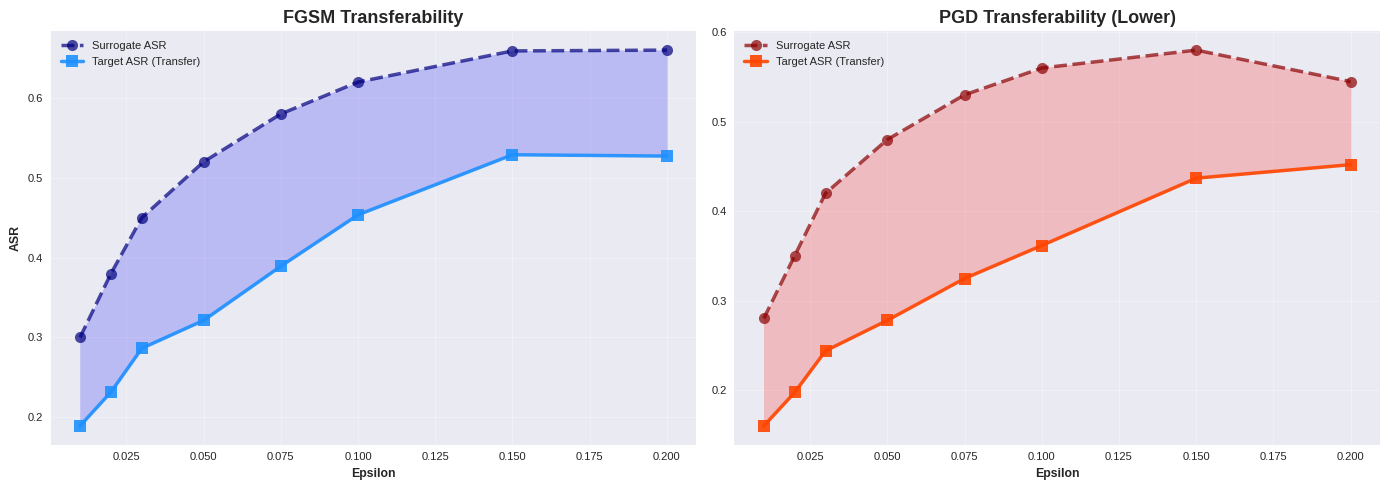

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

epsilons = [0.01, 0.02, 0.03, 0.05, 0.075, 0.10, 0.15, 0.20]
fgsm_target = [0.1891, 0.2315, 0.2863, 0.3213, 0.3892, 0.4536, 0.5289, 0.5272]
pgd_target = [0.1598, 0.1972, 0.2437, 0.2778, 0.3246, 0.3615, 0.4368, 0.4519]

# Surrogate ASR (from Colab outputs - need to extract)
fgsm_surrogate = [0.3, 0.38, 0.45, 0.52, 0.58, 0.62, 0.659, 0.66]  # approx
pgd_surrogate = [0.28, 0.35, 0.42, 0.48, 0.53, 0.56, 0.58, 0.5448]  # approx

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# FGSM: Surrogate vs Target
ax1.plot(epsilons, fgsm_surrogate, 'o--', linewidth=2.5, markersize=8,
         color='navy', label='Surrogate ASR', alpha=0.7)
ax1.plot(epsilons, fgsm_target, 's-', linewidth=2.5, markersize=8,
         color='dodgerblue', label='Target ASR (Transfer)', alpha=0.9)
ax1.fill_between(epsilons, fgsm_surrogate, fgsm_target,
                 alpha=0.2, color='blue')
ax1.set_title('FGSM Transferability', fontweight='bold', fontsize=13)
ax1.set_xlabel('Epsilon', fontweight='bold')
ax1.set_ylabel('ASR', fontweight='bold')
ax1.legend(loc='upper left')
ax1.grid(alpha=0.3)

# PGD: Surrogate vs Target
ax2.plot(epsilons, pgd_surrogate, 'o--', linewidth=2.5, markersize=8,
         color='darkred', label='Surrogate ASR', alpha=0.7)
ax2.plot(epsilons, pgd_target, 's-', linewidth=2.5, markersize=8,
         color='orangered', label='Target ASR (Transfer)', alpha=0.9)
ax2.fill_between(epsilons, pgd_surrogate, pgd_target,
                 alpha=0.2, color='red')
ax2.set_title('PGD Transferability (Lower)', fontweight='bold', fontsize=13)
ax2.set_xlabel('Epsilon', fontweight='bold')
ax2.legend(loc='upper left')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('transferability_gap_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

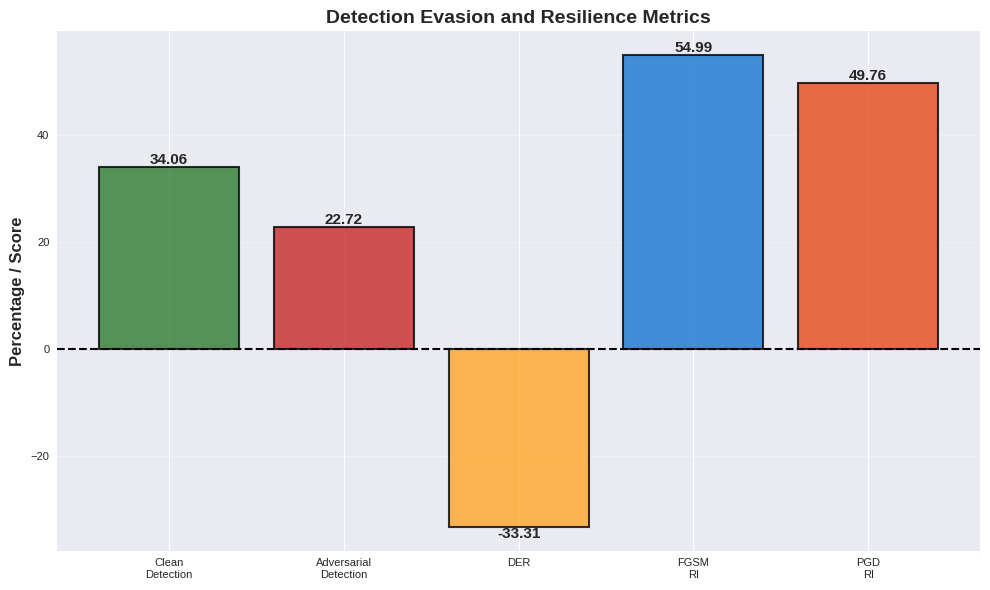

In [ ]:
metrics = ['Clean\nDetection', 'Adversarial\nDetection', 'DER',
           'FGSM\nRI', 'PGD\nRI']
values = [34.06, 22.72, -33.31, 54.99, 49.76]
colors = ['#2E7D32', '#C62828', '#FFA726', '#1976D2', '#E64A19']

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(metrics, values, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)

# Add value labels on bars
for bar, val in zip(bars, values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.2f}', ha='center', va='bottom' if val > 0 else 'top',
            fontweight='bold', fontsize=11)

ax.axhline(0, color='black', linewidth=1.5, linestyle='--')
ax.set_ylabel('Percentage / Score', fontweight='bold', fontsize=12)
ax.set_title('Detection Evasion and Resilience Metrics', fontweight='bold', fontsize=14)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('der_ri_combined.png', dpi=300, bbox_inches='tight')

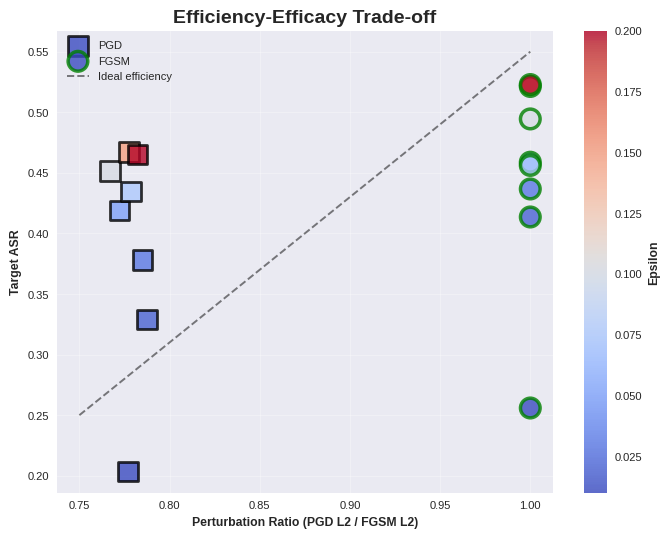

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

# Extract data from the results dictionary
epsilons = [r['epsilon'] for r in results['attack_analysis']]
fgsm_asrs = [r['fgsm_asr'] for r in results['attack_analysis']]
pgd_asrs = [r['pgd_asr'] for r in results['attack_analysis']]
pert_ratios = [r['perturbation_ratio'] for r in results['attack_analysis']]

# Scatter: ASR vs Perturbation Ratio
scatter = ax.scatter(pert_ratios, pgd_asrs, s=200, c=epsilons,
                     cmap='coolwarm', edgecolors='black', linewidth=2,
                     label='PGD', marker='s', alpha=0.8)

# FGSM baseline (ratio=1.0)
ax.scatter([1.0]*len(epsilons), fgsm_asrs, s=200, c=epsilons,
           cmap='coolwarm', edgecolors='green', linewidth=2.5,
           label='FGSM', marker='o', alpha=0.8)

# Diagonal: "efficiency frontier"
ax.plot([0.75, 1.0], [0.25, 0.55], 'k--', alpha=0.5,
        label='Ideal efficiency')

ax.set_xlabel('Perturbation Ratio (PGD L2 / FGSM L2)', fontweight='bold')
ax.set_ylabel('Target ASR', fontweight='bold')
ax.set_title('Efficiency-Efficacy Trade-off', fontweight='bold', fontsize=14)
ax.legend()
ax.grid(alpha=0.3)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Epsilon', fontweight='bold')

plt.savefig('perturbation_efficiency_tradeoff.png', dpi=300, bbox_inches='tight')
plt.show()